# GazeLLE

In [ ]:
GROUP_NAME = "gazelle_dinov2_vitl14" # gazelle_dinov2_vitb14_no_bbox, gazelle_dinov2_vitb14, gazelle_dinov2_vitl14_no_bbox, and gazelle_dinov2_vitl14
RESULT_PATH = "result_1771518084_20251124F_20260220F_20251123_20251124.csv"

## Setup

In [2]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance", "tidyr", "car")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("ggeffects", "strengejacke/ggeffects")

utils:::print.sessionInfo(sessionInfo()[-c(10,12,13)])

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.1

Matrix products: default


locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        car_3.1-3              carData_3.0-5         
 [4] tidyr_1.3.1            performance_0.14.0     parameters_0.28.3     
 [7] dplyr_1.1.4            ggplot2_3.5.1          marginaleffects_0.25.1
[10] readr_2.1.5            lme4_1.1-35.5          Matrix_1.6-5          


In [3]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE)
df <- df[df$Group == GROUP_NAME, ]
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

## On Stimuli B (Hypothesis-Driven)

In [4]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_unnatural <- df_B %>%
  filter(Condition %in% c("congruent", "incongruent")) %>% 
  mutate(offset_wrongness_head = qlogis(ExpectedDistToHeadTarget / MaxDistToHeadTarget),)
df_replicate <- df_B[df_B$Condition != "incongruent", ]

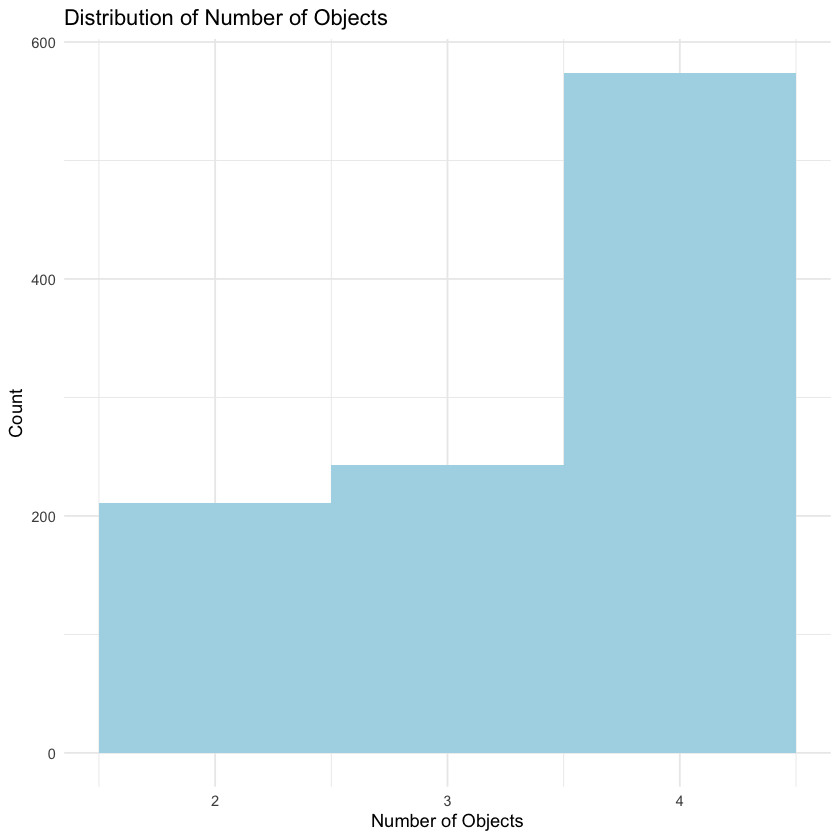

In [5]:
ggplot(df_unnatural, aes(x = n_candidates)) +
    geom_histogram(binwidth = 1, fill = "lightblue") +
    theme_minimal() +
    labs(
        title = "Distribution of Number of Objects",
        x = "Number of Objects",
        y = "Count"
    )

### Replicating the Proximity effect and the (lack of) View effect

In [6]:
#m_effects1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
#m_effects2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
#m_effects3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
#m_effects4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
#isSingular(m_effects1)
#isSingular(m_effects2)
#isSingular(m_effects3)
#isSingular(m_effects4)
#compare_performance(m_effects1, m_effects2, m_effects3, m_effects4, rank = TRUE)

In [7]:
#anova(m_effects2, m_effects3)
m_effects_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)

In [8]:
m_effects <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + Condition + offset(offset_wrongness) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
anova(m_effects, m_effects_c)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects,7,971.7801,1003.226,-478.890,957.7801,NA,NA,NA
m_effects_c,25,980.3261,1092.632,-465.163,930.3261,27.45399,18,0.07086515


In [9]:
avg_slopes(m_effects_c, variables = "Proximity")
avg_slopes(m_effects_c, variables = "n_candidates")
avg_comparisons(m_effects_c, variables = "Angle")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.1177476,0.01498101,7.85979,3.847779e-15,47.8849,0.08838537,0.1471099,0.490722,0.4907502,0.4907361


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,0.0486772,0.01904074,2.556477,0.01057382,6.56336,0.01135804,0.08599637,0.4907381,0.4907342,0.4907361


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.2046162,0.02799652,7.308627,2.698857e-13,41.75272,0.1497440,0.2594883
Angle,right - front,0.2444930,0.02820123,8.669587,4.336920e-18,57.67803,0.1892196,0.2997664


In [10]:
### Report
summary(m_effects)
Anova(m_effects, type = 3)
vc_list <- lapply(VarCorr(m_effects), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(m_effects)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

# The below code is for generating the table in the paper.
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

#actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
#actory_est <- res[res$term == actory_term_name, "Estimate"]
#actory_se <- res[res$term == actory_term_name, "Std. Error"]
#actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
#actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("View=left", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("View=right", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size))

    #c("ActorY", "b", sprintf("%.7f", actory_est)),
    #c("", "SE", sprintf("%.7f", actory_se)),
    #c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    #c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    Condition + offset(offset_wrongness) + (1 | Candidates)
   Data: df_replicate
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
   971.8   1003.2   -478.9    957.8      653 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8853 -0.6796 -0.3928  0.7821  2.5512 

Random effects:
 Groups     Name        Variance Std.Dev.
 Candidates (Intercept) 0.01448  0.1203  
Number of obs: 660, groups:  Candidates, 13

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -2.11338    0.17699 -11.941  < 2e-16 ***
scale(Proximity, scale = FALSE)     0.58241    0.08735   6.667 2.61e-11 ***
Angleleft                           1.16540  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),142.5817589,1,7.255682e-33
"scale(Proximity, scale = FALSE)",44.4526611,1,2.605825e-11
Angle,59.0287502,2,1.520792e-13
"scale(n_candidates, scale = FALSE)",4.7963415,1,2.852024e-02
Condition,0.1897447,1,6.631292e-01


term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-2.11338146,0.17698885,-11.940760,0.000000000000000000000000000000007255682,-2.46027961,-1.7664833,1.817785,-1.16261339
"scale(Proximity, scale = FALSE)",0.58241375,0.08735399,6.667283,0.000000000026058253215789661145201038832,0.41119994,0.7536276,1.817785,0.32039745
Angleleft,1.16539520,0.19034368,6.122584,0.000000000920697043457099608876453822846,0.79232159,1.5384688,1.817785,0.64110719
Angleright,1.41887630,0.18826263,7.536686,0.000000000000048206625459860209684845627,1.04988154,1.7878711,1.817785,0.78055222
"scale(n_candidates, scale = FALSE)",0.22413615,0.10234270,2.190055,0.028520238056099694173850522815882868599,0.02354446,0.4247278,1.817785,0.12330178
Conditioncongruent,-0.06027147,0.13836523,-0.435597,0.663129178347357628453551114944275468588,-0.33146733,0.2109244,1.817785,-0.03315654


NA
NA
NA
1.8177852
-2.1133815
0.1769889
1.1653952
0.1903437
0.0000000
0.6411072
1.4188763
0.1882626
0.0000000
0.7805522
0.5824138
0.0873540
0.0000000
0.3203974
0.2241362
0.1023427
0.0285202
0.1233018


### Test 2.1: Choose head targets more↑ often than gaze targets (when they differ).
Take results in the Incongruent Condition with #Objects greater than 2 and the responded object being either GazeTarget or HeadTarget. Fit a model with “IsHeadTarget ~ 1 + (1 | Objects) + (1 | StimulusID) + (1 | PromptID)” for each VLM. A significant positive intercept indicates a positive answer.

In [11]:
df_test21 <- df_B %>%
  filter(
    Condition == "incongruent",
    n_candidates > 2,
    (Choice == HeadTarget | Choice == label) # Keep only trials where the choice was one of the two cues
  )

mean(df_test21$IsHeadTarget)
m_head_bias <- glmer(
  IsHeadTarget ~ 1 + (1 | Candidates),
#  IsHeadTarget ~ 1 + (1 | Candidates) + (1 | Stimulus_ID) + (1 | Prompt_ID),
  data = df_test21, 
  family = binomial
)
summary(m_head_bias)

[1] 0.7317073

boundary (singular) fit: see help('isSingular')



Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: IsHeadTarget ~ 1 + (1 | Candidates)
   Data: df_test21

     AIC      BIC   logLik deviance df.resid 
   480.9    488.9   -238.4    476.9      408 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.6515 -1.6515  0.6055  0.6055  0.6055 

Random effects:
 Groups     Name        Variance Std.Dev.
 Candidates (Intercept) 0        0       
Number of obs: 410, groups:  Candidates, 7

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.0033     0.1115   9.001   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
optimizer (Nelder_Mead) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


### Test 2.2: When head orientation is fixed but only eye appearance varies, responses stay the same much more often than chance?
Take results in the Congruent and Incongruent Conditions. Fix a combination of (#Objects, Objects, Proximity, View, HeadTarget), vary only GazeTarget (2-4 levels). Calculate the number of combinations where the Choice stays the same. Compare the rate of such to chance using a directional one-sample t-test. Rejecting the null hypothesis indicates a positive answer.

In [12]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    # Formula: (1 / n_candidates) ^ (steps - 1)
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 1)
  )

cat("Actual Stability Rate: ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
t.test(df_test22$is_stable, mu = mean(df_test22$chance_baseline), alternative = "greater")

Actual Stability Rate:  0.9249249 
Random Chance Baseline: 0.203735 



	One Sample t-test

data:  df_test22$is_stable
t = 49.867, df = 332, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0.203735
95 percent confidence interval:
 0.9010703       Inf
sample estimates:
mean of x 
0.9249249 


### Test 2.3: Performance when the HeadTarget = the GazeTarget is much higher↑ than when they differ?
Take results in the Congruent and Incongruent Conditions. Fit “IsCorrect ~ Proximity * View * #Object  * Condition + (1|Random Effects)” with offset being the chance accuracy. If the marginal prediction of Condition indicates that accuracy is higher in the congruent condition than in the incongruent condition, then this claim is supported.

In [13]:
mean(df_B[df_B$Condition == "congruent", ]$Accuracy)
mean(df_B[df_B$Condition == "incongruent", ]$Accuracy)

[1] 0.6128049

[1] 0.19

In [14]:
model_cond <- glm(Accuracy ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) * Condition + offset(offset_accuracy), data = df_unnatural, family = binomial)
#model_cond <- glmer(Accuracy ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) * Condition + offset(offset_accuracy) + (1|Candidates) + (1|Stimulus_ID) + (1|Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
#isSingular(model_cond)

In [15]:
avg_predictions(model_cond, variables = "Condition")

Condition,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
congruent,0.5760726,0.02621019,21.97895,4.578806e-107,353.2513,0.5247016,0.6274436
incongruent,0.1928444,0.01446893,13.32818,1.587250e-40,132.2106,0.1644859,0.2212030


In [16]:
avg_predictions(model_cond, variables = "Condition", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(incongruent) - (congruent),-0.3832282,0.02993867,-12.80044,1.630243e-37,122.2063,-0.4419069,-0.3245494


### Test 2.4: Fix the GazeTarget, as the HeadTarget moves farther away from the GazeTarget, their responses also move farther away from the GazeTarget?

Here, the distance is one plus the number of objects between them.
Take results in the Congruent and Incongruent Conditions. Fit “cbind(Wrongness, MaxWrongness - Wrongness) ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects)” with offset again being the chance baseline. If the marginal slope indicates that as DistEyeHead increases, the relative Wrongness also increases, then the answer is yes.

In [17]:
#m_dist1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
#m_dist2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
#m_dist3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
#m_dist4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_unnatural, family = binomial, control = strict_control)
    
#isSingular(m_dist1)
#isSingular(m_dist2)
#isSingular(m_dist3)
#isSingular(m_dist4)
#compare_performance(m_dist1, m_dist2, m_dist3, m_dist4, rank = TRUE)

In [18]:
m_dist_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_dist <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
anova(m_dist_c, m_dist)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_dist,7,1890.850,1925.397,-938.4249,1876.850,NA,NA,NA
m_dist_c,25,1768.882,1892.266,-859.4408,1718.882,157.9682,18,2.080388e-24


In [19]:
avg_slopes(m_dist_c, variables = "DistEyeHead")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.2128506,0.01309427,16.25524,2.050482e-59,194.9578,0.1871863,0.2385149,0.5256879,0.5256958,0.5256918


boundary (singular) fit: see help('isSingular')

Warning message:
“Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`).”
boundary (singular) fit: see help('isSingular')

Warning message:
“Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`).”


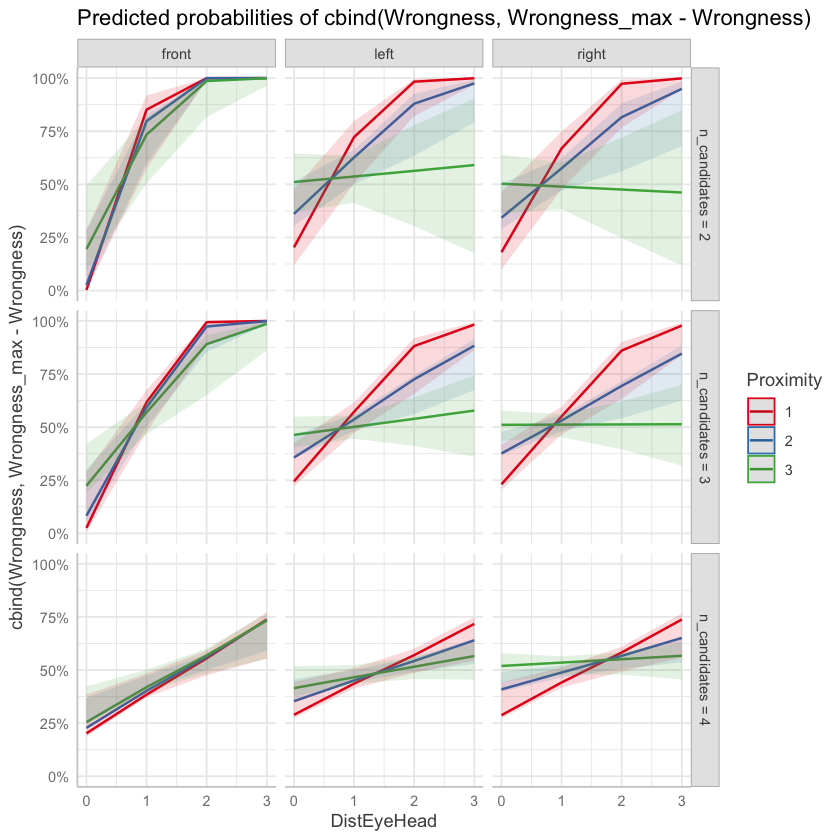

In [20]:
plot(ggpredict(
  m_dist_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]"),
  bias_correction = TRUE
))

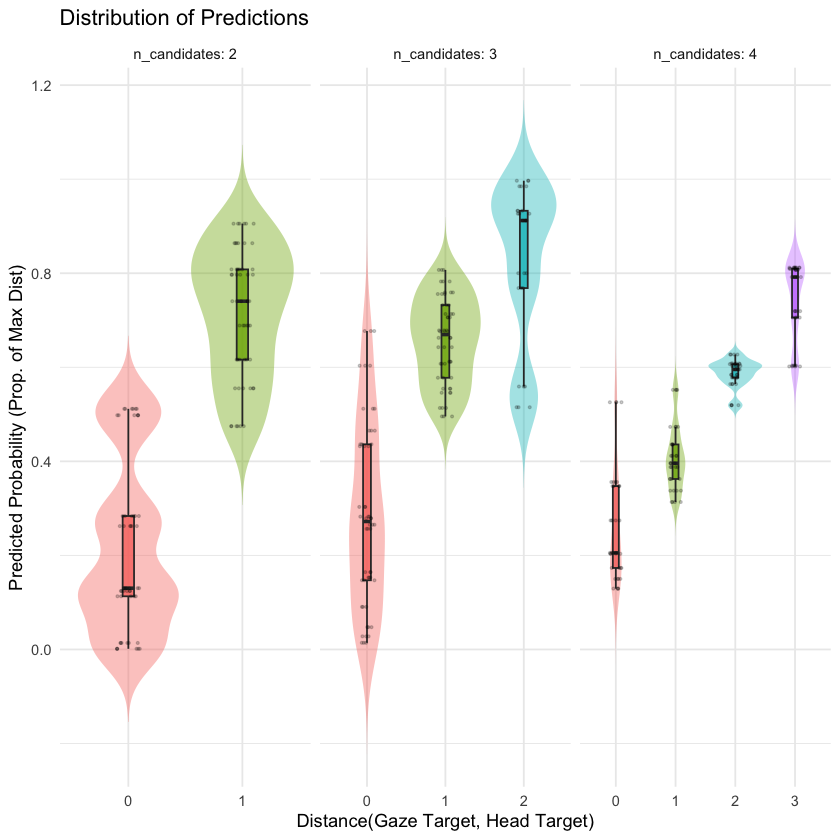

In [21]:
valid_grid <- df_unnatural %>%
    distinct(Proximity, Angle, DistEyeHead, n_candidates, offset_wrongness, Candidates)
preds <- predictions(m_dist_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)

ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

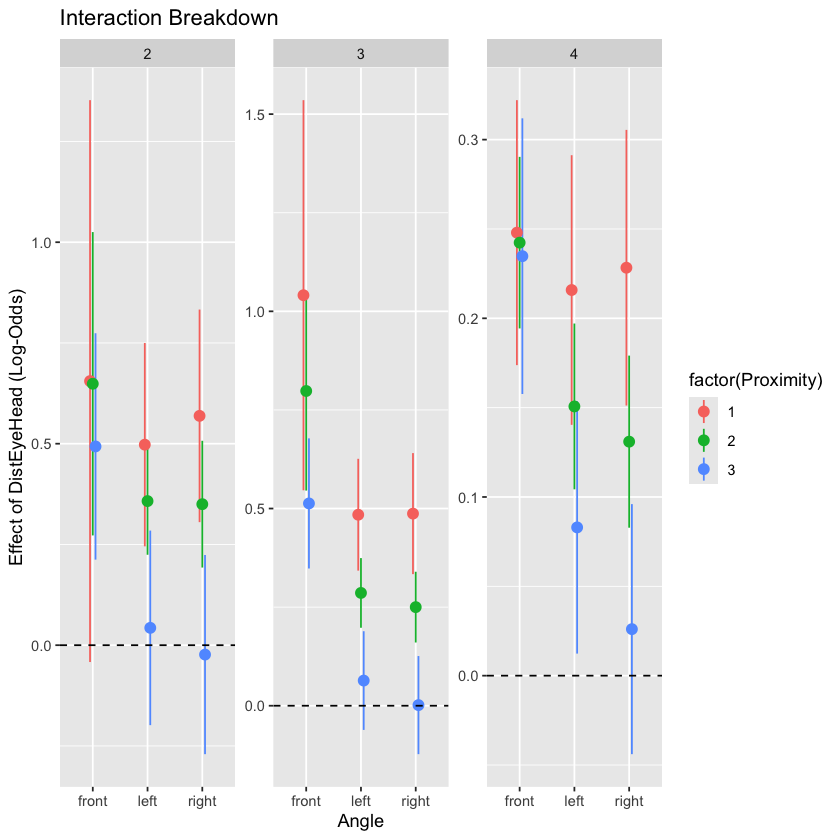

In [22]:
plot_slopes(
  m_dist_c,
  variables = "DistEyeHead",
  condition = c("Angle", "Proximity", "n_candidates") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of DistEyeHead (Log-Odds)", title = "Interaction Breakdown")

In [23]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Proximity")

term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,1,0.2882814,0.02115140,13.629423,2.676877e-42,138.10043,0.24682543,0.3297374
DistEyeHead,dY/dX,2,0.2301719,0.01264075,18.208726,4.400664e-74,243.68496,0.20539649,0.2549473
DistEyeHead,dY/dX,3,0.1216290,0.02149832,5.657604,1.535011e-08,25.95718,0.07949305,0.1637649


In [24]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Angle", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),-0.11177775,0.03311497,-3.375445,7.369652e-04,10.406116,-0.17668190,-0.04687360
(right) - (front),-0.13640413,0.03373756,-4.043094,5.275053e-05,14.210455,-0.20252853,-0.07027972
(right) - (left),-0.02462638,0.02921528,-0.842928,3.992687e-01,1.324568,-0.08188727,0.03263452


### Test 3: Fix the HeadTarget. As the GazeTarget moves farther away from the HeadTarget, do their responses move farther away from the HeadTarget?
Take results in the Congruent and Incongruent Conditions. Fit “cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ Proximity * Angle * #Objects * DistEyeHead + (1|Random Effects)” with offset being the chance baseline logit(ExpectedDistToHeadTarget / MaxDistToHeadTarget). If the marginal slope indicates that as DistEyeHead increases, the relative DistToHeadTarget also increases, then the answer is yes.

In [25]:
m_head_c <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_head <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
anova(m_head_c, m_head)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_head,7,1623.227,1657.775,-804.6137,1609.227,NA,NA,NA
m_head_c,25,1616.855,1740.239,-783.4273,1566.855,42.37282,18,0.0009806782


In [26]:
avg_slopes(m_head_c, variables = "DistEyeHead")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,-0.002266484,0.01251049,-0.1811666,0.8562368,0.2239183,-0.0267866,0.02225363,0.5246975,0.5246886,0.524693


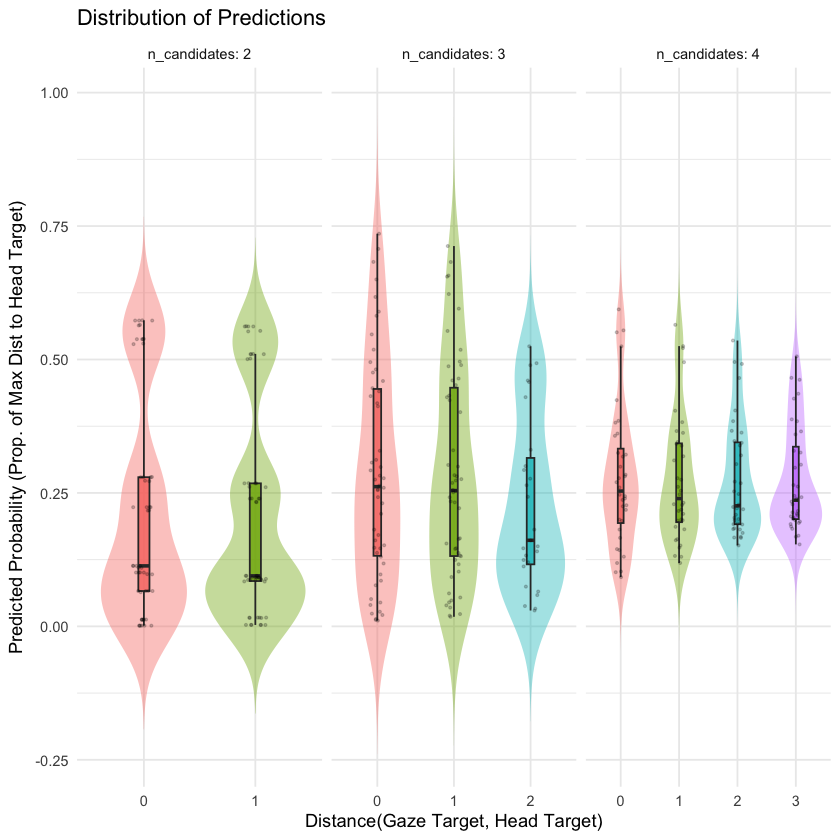

In [27]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_wrongness_head, Candidates)
preds <- predictions(m_head_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist to Head Target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.



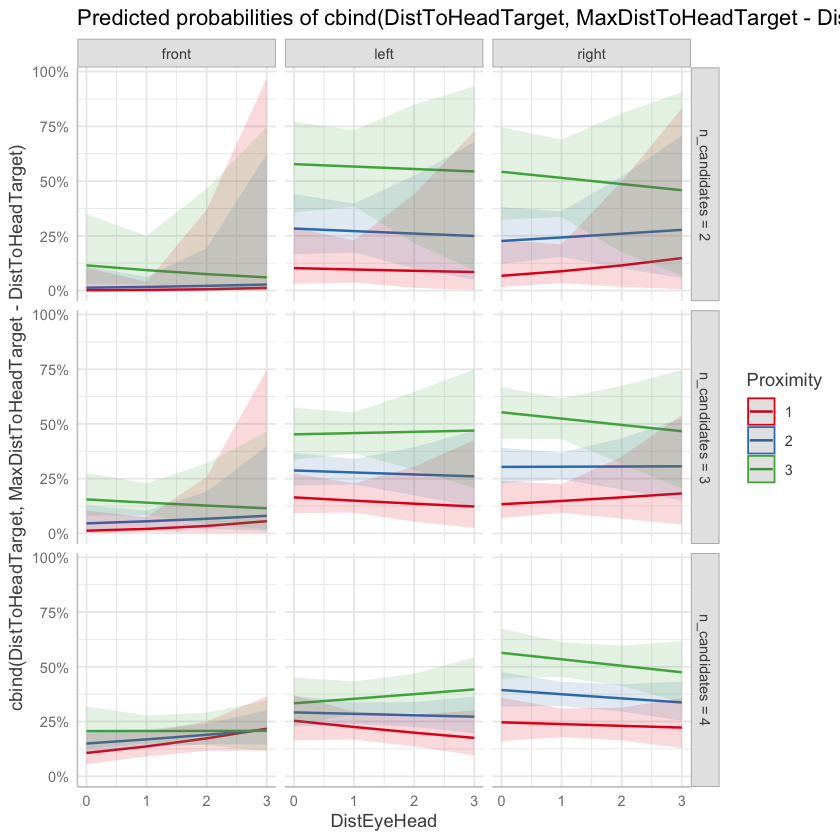

In [28]:
plot(ggpredict(
  m_head_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]")
))

### Test 4: How exactly does Frequency(response=head target) correlate with distance(head target, gaze target)? 
This will distinguish between Possibilities 4 & 5. Possibility 4 predicts that Frequency(response=head target) correlates negatively with distance(head target, gaze target), while Possibility 5 predicts that Frequency(response=head target) jumps down only when distance(head target, gaze target) goes from 0 to 1, but stays the same after that. If the relation turns out not to be a negative correlation, then these two explanations are incomplete. 

Take results in the Congruent and Incongruent Conditions with #Objects greater than 2. Fit “IsHeadTarget ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects).” Here, DistEyeHead is treated as categorical. Separately looking at #Object=3 and 4, the marginal means of IsHeadTarget for DistEyeHead=1 and 2 (or 1, 2, and 3 for #Object=4) are not significantly different from each other, but are all significantly lower than when DistEyeHead=0, then Possibility 5 is supported. Otherwise, if the marginal mean in general decreases, then Possibility 4 is supported.

In [29]:
m_3obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Candidates), data = df_unnatural[df_unnatural$n_candidates == 3, ], family = binomial, control = strict_control)

In [30]:
m_4obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Candidates), data = df_unnatural[df_unnatural$n_candidates == 4, ], family = binomial, control = strict_control)

In [31]:
avg_predictions(m_3obj, variables = "DistEyeHead", hypothesis = ~ pairwise)
avg_predictions(m_4obj, variables = "DistEyeHead", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),-0.01543966,0.06321873,-0.2442260,0.8070558,0.3092597,-0.13934609,0.1084668
(2) - (0),0.06840749,0.07636204,0.8958312,0.3703429,1.4330663,-0.08125935,0.2180743
(2) - (1),0.08384715,0.07190891,1.1660190,0.2436068,2.0373739,-0.05709172,0.2247860


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),-0.005974314,0.05164956,-0.1156702,0.9079139,0.1393726,-0.1072056,0.09525696
(2) - (0),-0.011529804,0.05700544,-0.2022579,0.8397151,0.2520282,-0.1232584,0.10019881
(3) - (0),-0.058955592,0.06855068,-0.8600292,0.3897729,1.3592942,-0.1933125,0.07540128
(2) - (1),-0.005555490,0.05143272,-0.1080147,0.9139840,0.1297591,-0.1063618,0.09525080
(3) - (1),-0.052981278,0.06398395,-0.8280401,0.4076478,1.2946050,-0.1783875,0.07242496
(3) - (2),-0.047425788,0.06838779,-0.6934832,0.4880064,1.0350282,-0.1814634,0.08661183


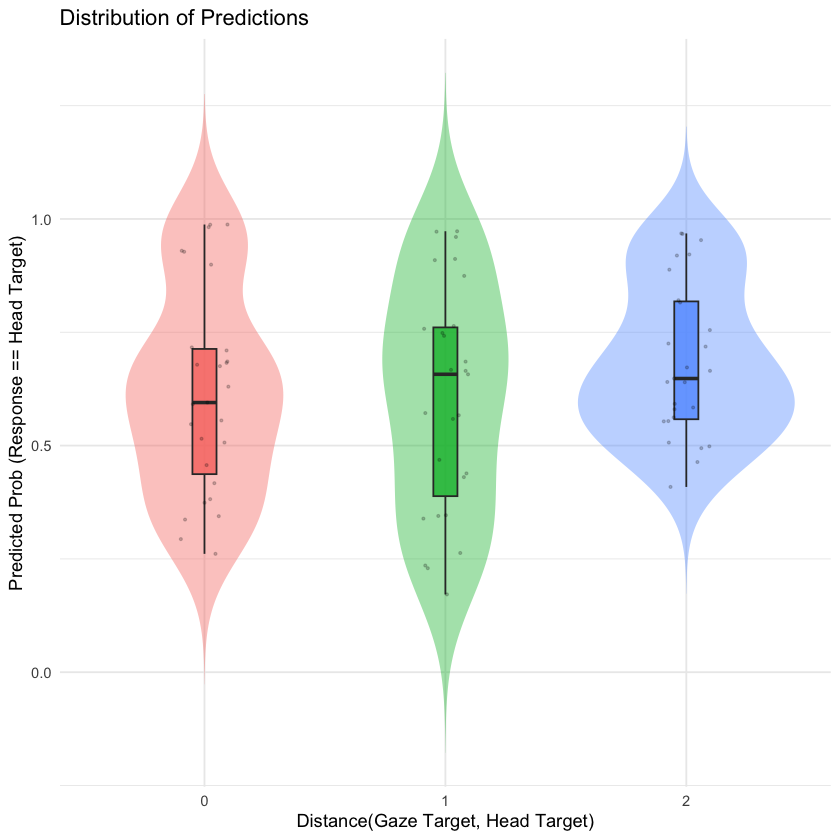

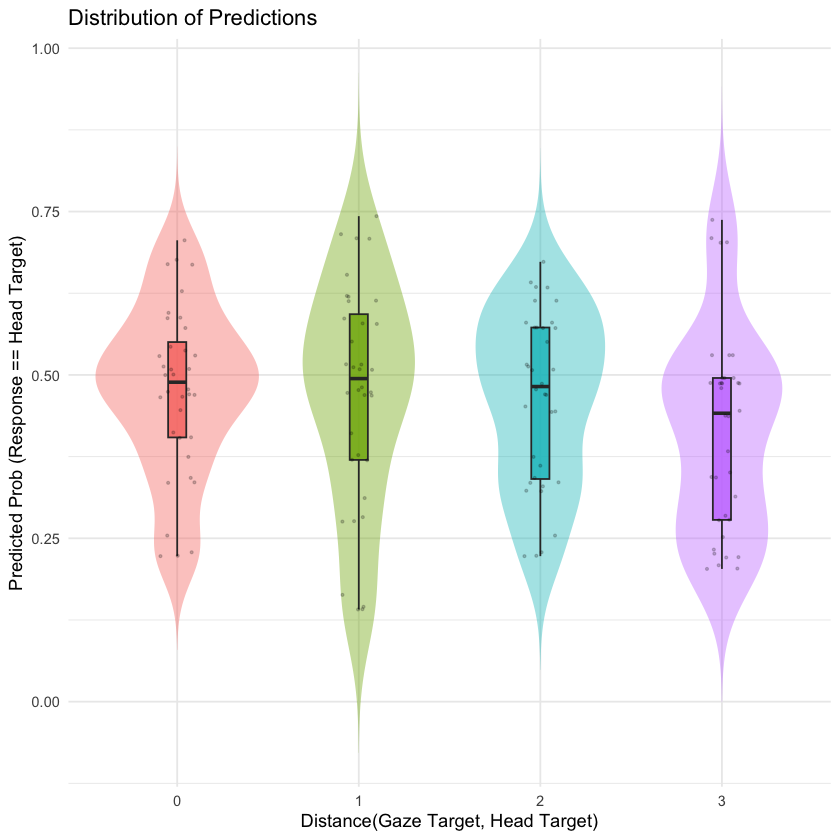

In [32]:
plot_head_preds <- function(model, data, x_var = "DistEyeHead", facet_var = NULL) {
  
  # 1. Define the columns we absolutely need for the prediction grid
  #    (Predictors + Random Effect Group + Offset)
  needed_cols <- c(x_var, "Candidates", "Proximity", "Angle", "offset_accuracy")
  if (!is.null(facet_var)) needed_cols <- c(needed_cols, facet_var)
  
  # 2. Create the valid_grid
  #    We use distinct() to avoid predicting on 20,000 rows if we only need
  #    unique condition+candidate combinations.
  valid_grid <- data %>%
    select(all_of(intersect(needed_cols, names(data)))) %>%
    distinct()
  
  # 3. Generate Predictions
  #    type="response" ensures we get probabilities (0-1)
  preds <- predictions(model, newdata = valid_grid, type = "response")
  
  # 4. Prepare for plotting
  #    Convert x_var to factor so violin plots work properly
  preds[[x_var]] <- as.factor(preds[[x_var]])
  
  # 5. Build the Plot
  p <- ggplot(preds, aes(x = .data[[x_var]], y = estimate, fill = .data[[x_var]])) +
    # The Violin: Density across items
    geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
    
    # The Boxplot: Summary stats
    geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
    
    # Jitter: Individual item points
    geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +
    
    # Labels
    labs(
      x = "Distance(Gaze Target, Head Target)",
      y = "Predicted Prob (Response == Head Target)",
      title = "Distribution of Predictions"
    ) +
    theme_minimal() +
    theme(legend.position = "none")
  
  # 6. Add Faceting conditionally
  if (!is.null(facet_var)) {
    p <- p + facet_wrap(as.formula(paste("~", facet_var)), 
                        labeller = label_both, 
                        scales = "free_x")
  }
  
  return(p)
}

plot_head_preds(
  model = m_3obj, 
  data = df_unnatural[df_unnatural$n_candidates == 3, ]
)
plot_head_preds(
  model = m_4obj, 
  data = df_unnatural[df_unnatural$n_candidates == 4, ]
)

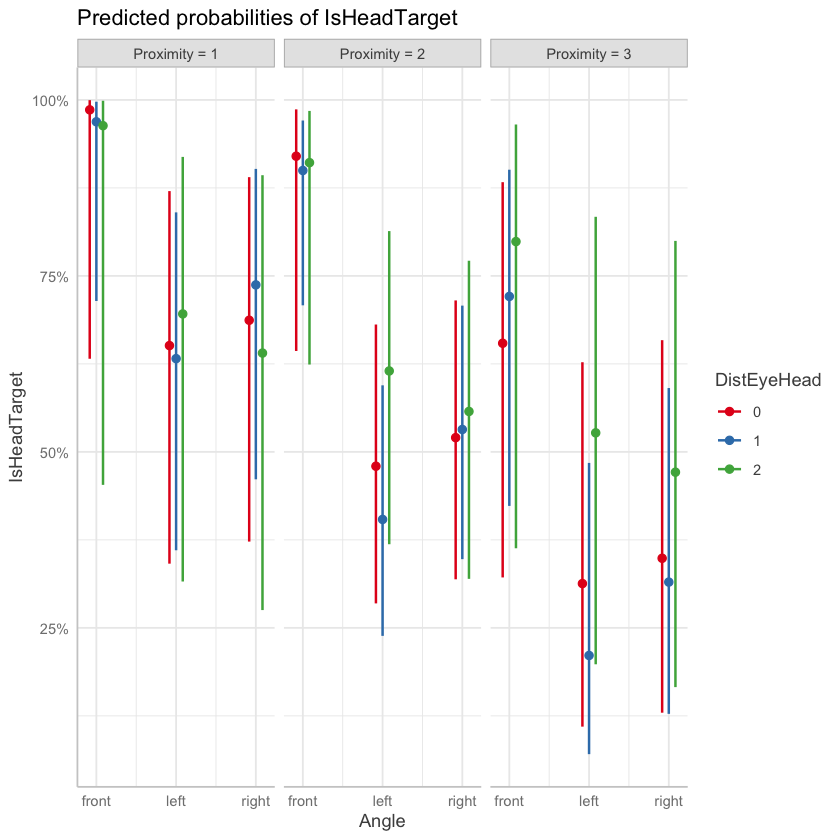

In [33]:
plot(ggpredict(
  m_3obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

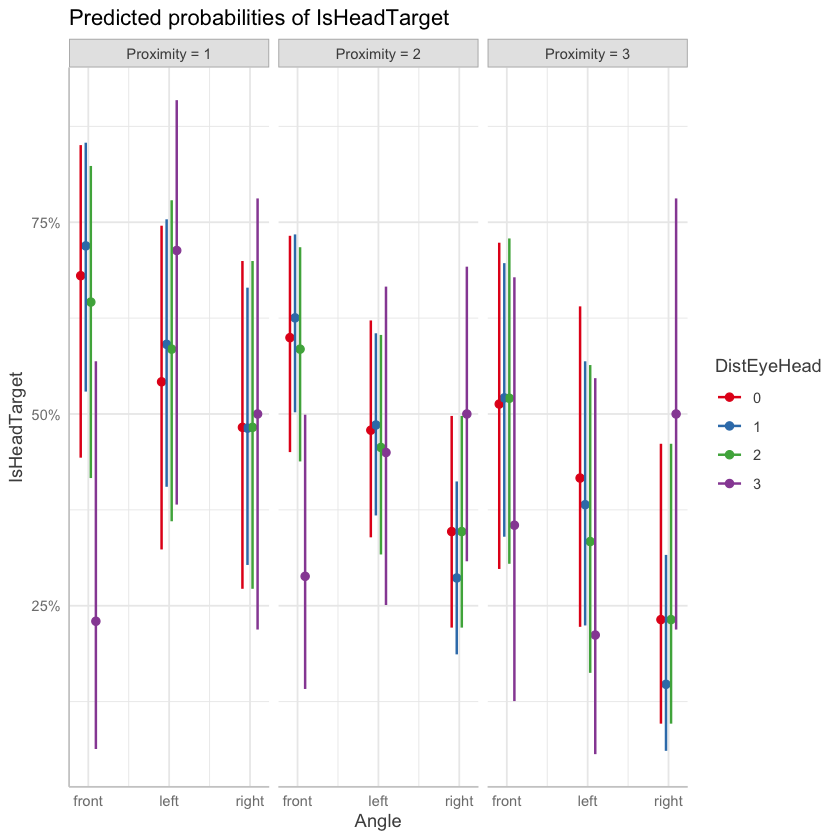

In [34]:
plot(ggpredict(
  m_4obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

### Look at View effects in different conditions (Exploratory)

In [35]:
df_view <- df_B %>%
  mutate(DistEyeHead = factor(replace_na(DistEyeHead, -1)))
  
model_view <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + DistEyeHead + offset(offset_wrongness) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)
model_view_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * DistEyeHead + offset(offset_wrongness) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)
anova(model_view, model_view_c)

boundary (singular) fit: see help('isSingular')

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients

boundary (singular) fit: see help('isSingular')



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_view,10,2424.559,2476.712,-1202.280,2404.559,NA,NA,NA
model_view_c,55,2288.422,2575.260,-1089.211,2178.422,226.1379,45,5.689701e-26


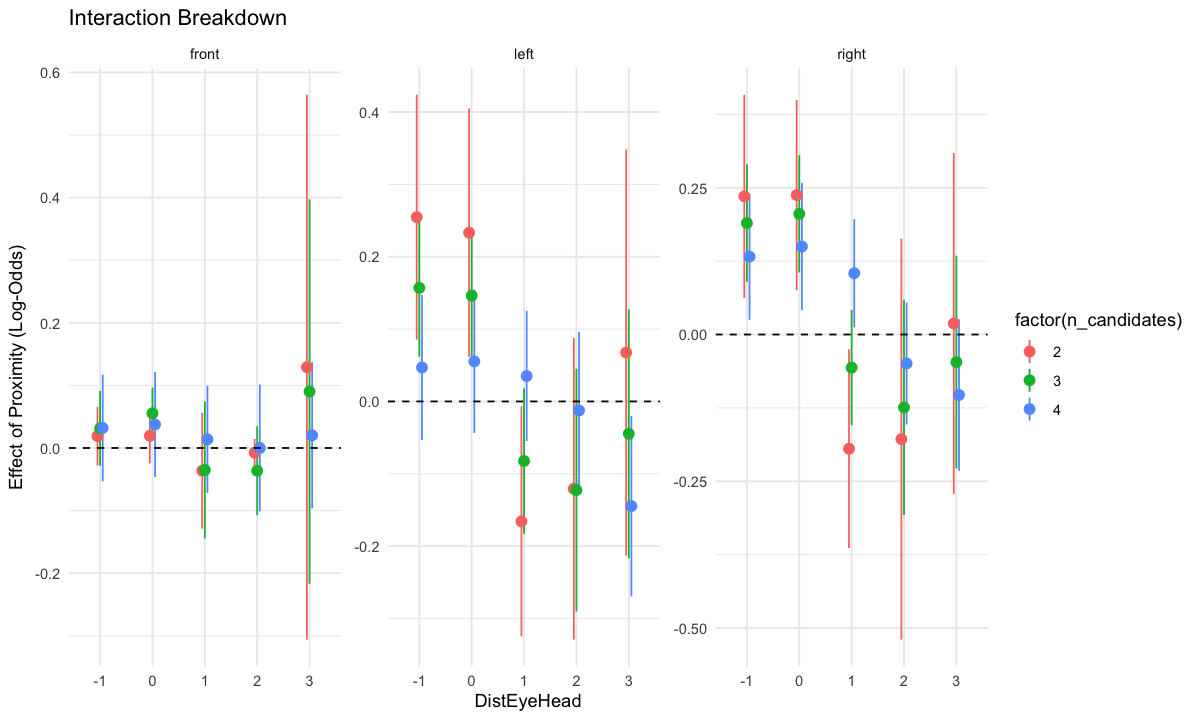

In [36]:
options(repr.plot.width=10, repr.plot.height=6)
plot_slopes(
  model_view_c,
  variables = "Proximity",
  condition = c("DistEyeHead", "n_candidates", "Angle") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

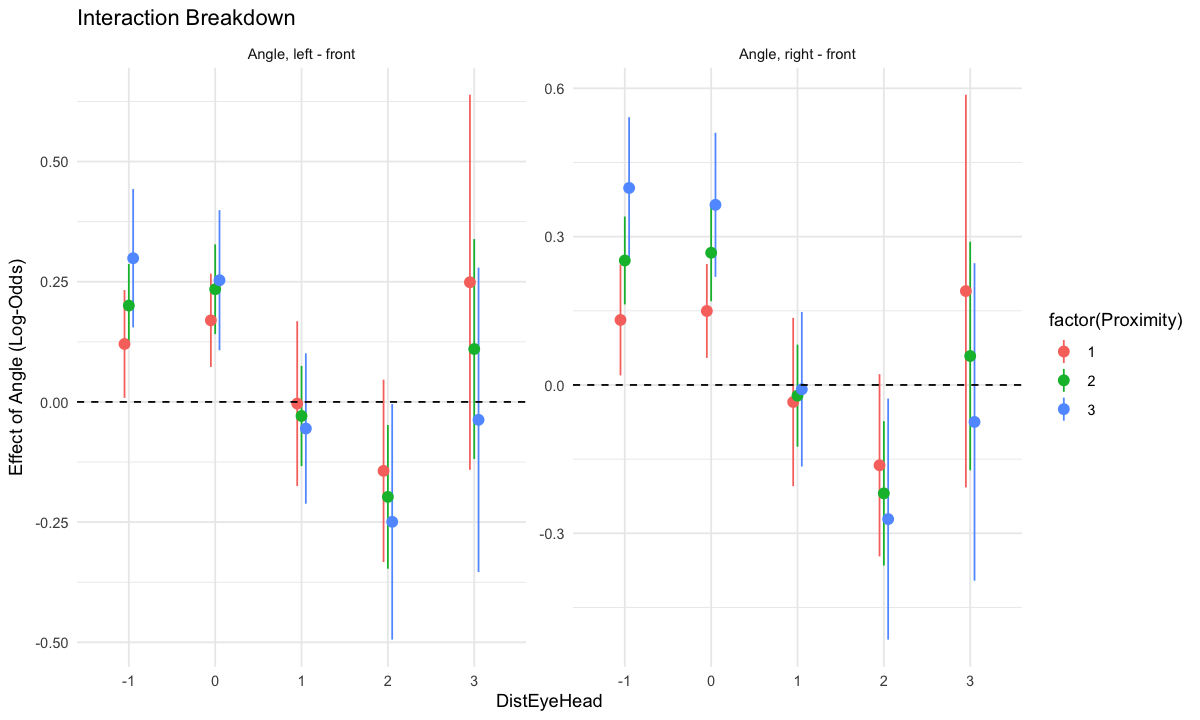

In [37]:
plot_slopes(
  model_view_c,
  variables = "Angle",
  condition = c("DistEyeHead", "Proximity") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Angle (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

## On Stimuli A (Pilot)

This part is exploratory and not a concern of the pre-registration.

In [38]:
df_A <- df[df$Site == "Site0", ] # take Stimuli A results only
m_A_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + Actor + offset(offset_wrongness) + (1 | Actor:Candidates), data = df_A, family = binomial, control = strict_control)
m_A <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale=FALSE) + Actor + offset(offset_wrongness) + (1 | Actor:Candidates), data = df_A, family = binomial, control = strict_control)
isSingular(m_A_c)
isSingular(m_A)
anova(m_A, m_A_c)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



[1] TRUE

[1] TRUE

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_A,7,1323.882,1357.499,-654.9412,1309.882,NA,NA,NA
m_A_c,14,1327.531,1394.764,-649.7653,1299.531,10.35175,7,0.1695007


In [39]:
avg_slopes(m_A, variables = "Proximity")
avg_slopes(m_A, variables = "n_candidates")
avg_comparisons(m_A, variables = "Angle")
avg_predictions(m_A, variables = "Actor", hypothesis = ~ pairwise, allow.new.levels = TRUE)

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.09889183,0.01469674,6.728827,1.710366e-11,35.7669,0.07008674,0.1276969,0.2356982,0.2357163,0.2357073


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,-0.007963632,0.01457768,-0.5462895,0.5848669,0.7738196,-0.03653535,0.02060809,0.235708,0.2357065,0.2357073


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.12603230,0.03017834,4.176251,2.963533e-05,15.042322,0.06688384,0.1851807
Angle,right - front,0.07840572,0.02982871,2.628532,8.575432e-03,6.865575,0.01994252,0.1368689


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Y) - (X),0.2513196,0.02598592,9.671375,3.98981e-22,71.0861,0.2003881,0.3022511


## On Stimuli A & B (Exploratory) 

In [40]:
m1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | ActorSite) + (1 | ActorSite:Candidates), data = df, family = binomial, control = strict_control)
m2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | ActorSite), data = df, family = binomial, control = strict_control)
m3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | Candidates), data = df, family = binomial, control = strict_control)
compare_performance(m1, m2, m3, rank = TRUE)

boundary (singular) fit: see help('isSingular')

Some of the nested models seem to be identical and probably only vary in
  their random effects.

boundary (singular) fit: see help('isSingular')



Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

Following indices with missing values are not used for ranking:
  R2_conditional, Sigma, Log_loss, ICC



Name,Model,R2_conditional,R2_marginal,RMSE,Sigma,Log_loss,ICC,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m2,glmerMod,0.1495454,0.05642466,0.4054084,1,NA,0.09868922,7.310586e-01,7.335107e-01,9.793982e-01,0.6000000
m3,glmerMod,0.1415436,0.06241812,0.4042669,1,NA,0.08439313,1.777969e-10,1.783933e-10,2.381943e-10,0.4000000
m1,glmerMod,NA,0.06221848,0.4054084,1,NA,NA,2.689414e-01,2.664893e-01,2.060180e-02,0.3437828


In [41]:
m1_simple <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | ActorSite) + (1 | ActorSite:Candidates), data = df, family = binomial, control = strict_control)
anova(m1, m1_simple)

boundary (singular) fit: see help('isSingular')



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m1_simple,7,4130.269,4170.331,-2058.135,4116.269,NA,NA,NA
m1,14,4122.044,4202.168,-2047.022,4094.044,22.22463,7,0.002323453


In [42]:
model <- m1_simple
summary(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    offset(offset_wrongness) + (1 | ActorSite) + (1 | ActorSite:Candidates)
   Data: df
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  4130.3   4170.3  -2058.1   4116.3     2253 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9561 -0.8858 -0.3125  0.9664  2.9995 

Random effects:
 Groups               Name        Variance  Std.Dev. 
 ActorSite:Candidates (Intercept) 1.236e-14 1.112e-07
 ActorSite            (Intercept) 2.003e-01 4.476e-01
Number of obs: 2260, groups:  ActorSite:Candidates, 31; ActorSite, 4

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -0.76536    0.23225  -3.295 0.000983 ***
scale(Proxim

In [43]:
avg_slopes(model, variables = "Proximity")
avg_slopes(model, variables = "n_candidates")
avg_comparisons(model, variables = "Angle")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.05399414,0.009365743,5.765068,8.162504e-09,26.86834,0.03563762,0.07235066,0.2125002,0.2125082,0.2125042


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,0.005454205,0.01007967,0.5411097,0.588432,0.7650525,-0.01430158,0.02520999,0.2125038,0.2125046,0.2125042


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.07991458,0.01868914,4.275989,1.902905e-05,15.68144,0.04328453,0.1165446
Angle,right - front,0.09036802,0.01878407,4.810885,1.502635e-06,19.34407,0.05355191,0.1271841


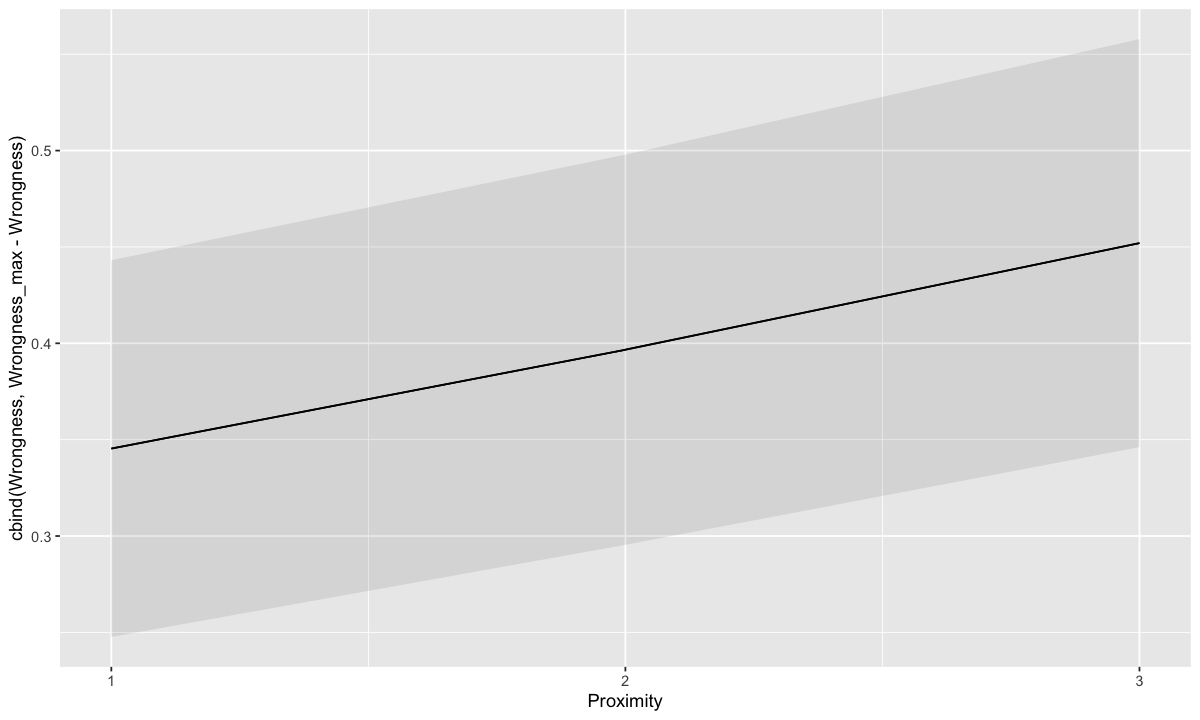

In [44]:
plot_predictions(model, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))

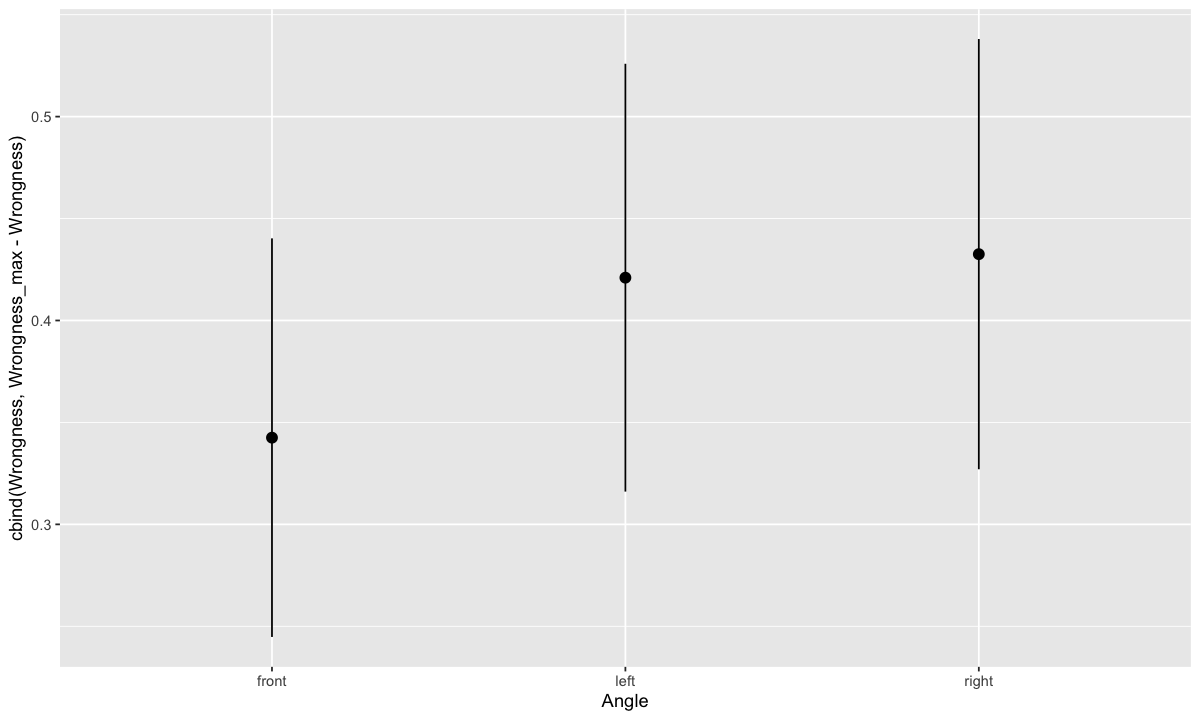

In [45]:
plot_predictions(model, by = c("Angle"))

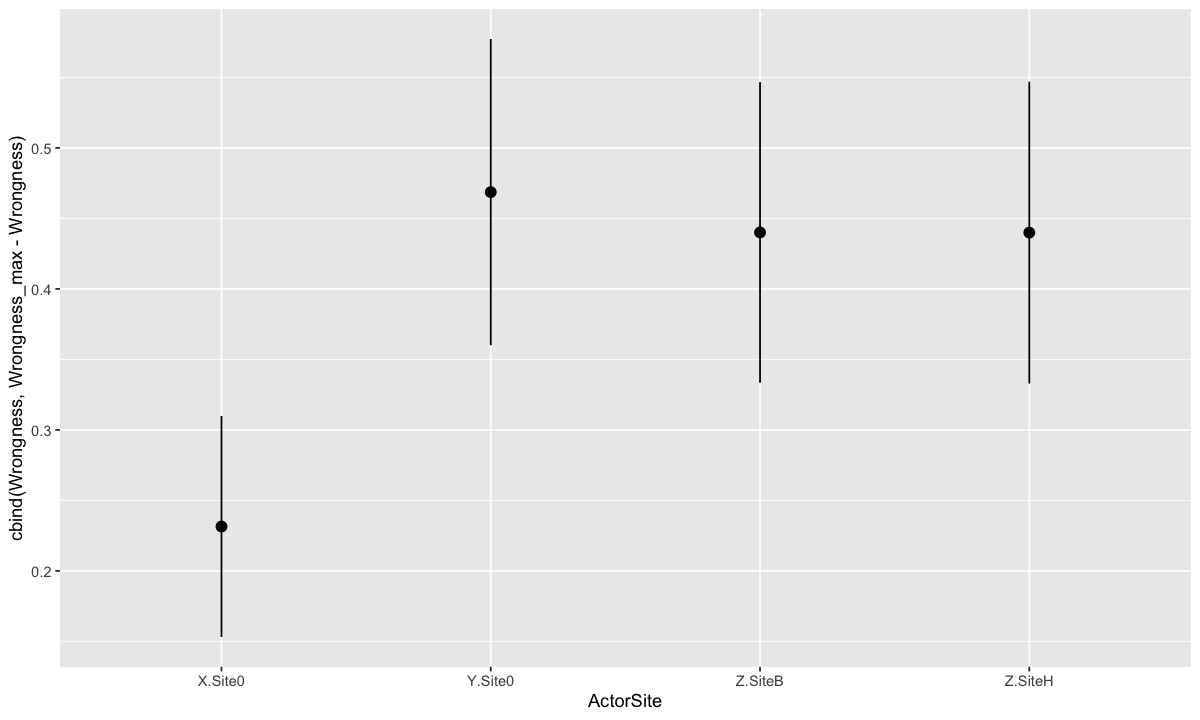

In [46]:
plot_predictions(model, by = c("ActorSite"))

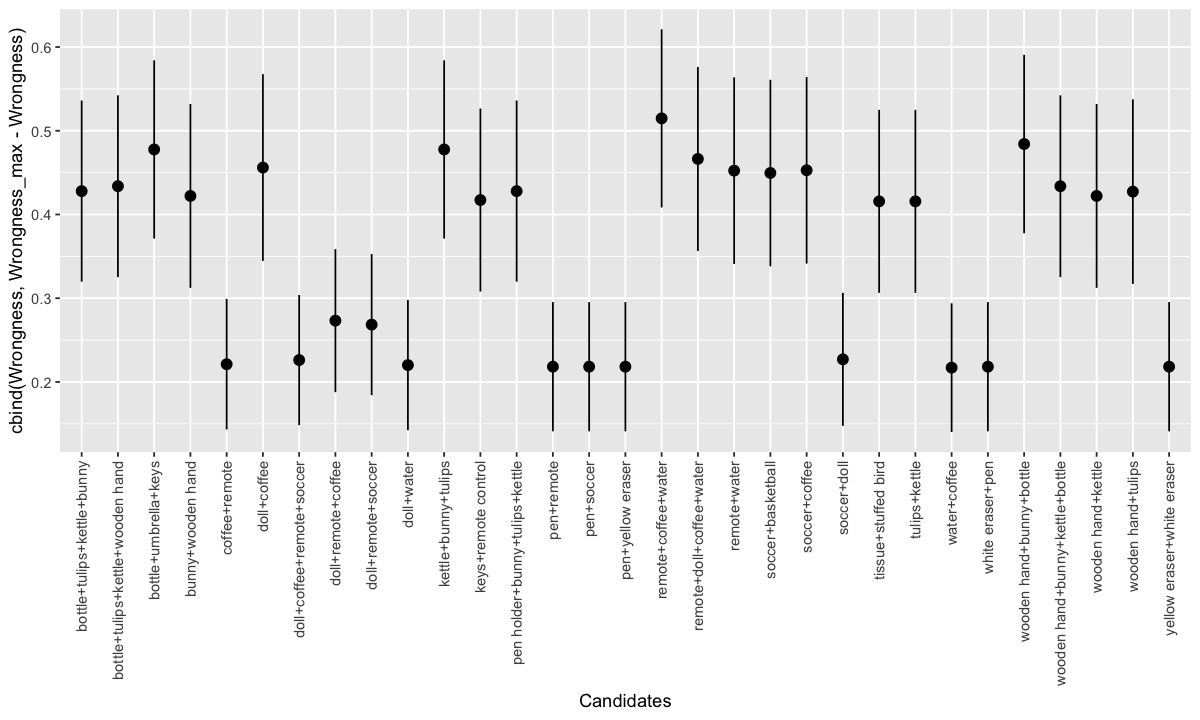

In [47]:
plot_predictions(model, by = c("Candidates")) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

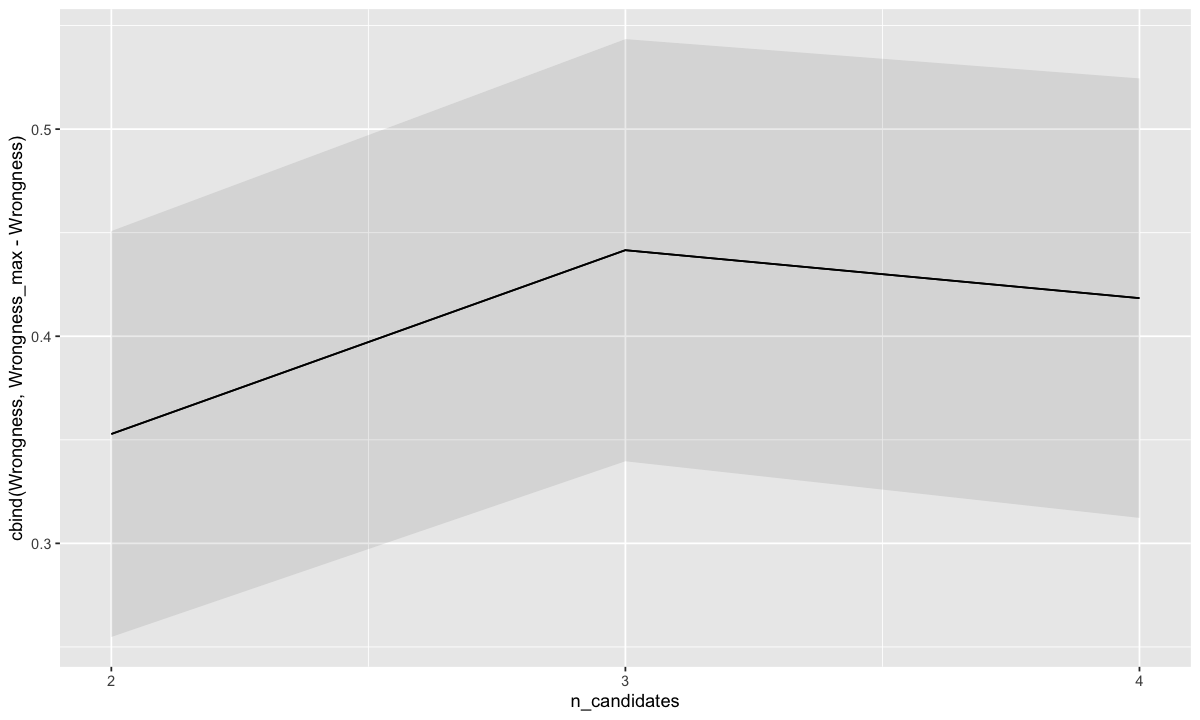

In [48]:
plot_predictions(model, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))